# PricePredictor — Backtesting et intérêt pratique (3/3)

**Data Analyst — Finance, Business Intelligence et Aide à la décision**

Dernière étape, et la plus importante pour répondre à la question initiale du client : *"est-ce que ça a un intérêt concret pour un investisseur particulier ?"*

Un modèle avec un RMSE légèrement meilleur (notebook précédent) n'a d'intérêt pratique que s'il se traduit par une meilleure décision d'allocation, **frais de transaction inclus**.

**Règle de la stratégie testée :** investi si le modèle prédit un rendement positif, en cash sinon. Comparée à un simple "acheter et garder" (buy-and-hold).

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

COST = 0.0005  # hypothese : 5 points de base de frais a chaque changement de position

def backtest(y_true, signal):
    positions = np.array(signal, dtype=float)
    prev_position = np.roll(positions, 1)
    prev_position[0] = 0
    nb_trades = np.sum(positions != prev_position)
    couts = np.where(positions != prev_position, COST, 0.0)
    rendements_nets = positions * y_true - couts
    croissance = np.cumprod(1 + rendements_nets) - 1
    return croissance, nb_trades

signal_rf = (pred_rf > 0).astype(int)
signal_lin = (pred_lin > 0).astype(int)
signal_buyhold = np.ones(len(y_test), dtype=int)

croissance_rf, trades_rf = backtest(y_test, signal_rf)
croissance_lin, trades_lin = backtest(y_test, signal_lin)
croissance_bh, trades_bh = backtest(y_test, signal_buyhold)


> Cellule ci-dessus : suite directe du notebook de modélisation (`pred_rf`, `pred_lin`, `y_test` déjà calculés).

## Résultats sur la période de test (12 jours de bourse)

In [2]:
resume = pd.DataFrame([
    {"Strategie": "Acheter et garder (buy-and-hold)",
     "Rendement cumule (%)": round(croissance_bh[-1]*100, 2), "Nb transactions": trades_bh},
    {"Strategie": "Basee sur Random Forest",
     "Rendement cumule (%)": round(croissance_rf[-1]*100, 2), "Nb transactions": trades_rf},
    {"Strategie": "Basee sur regression lineaire",
     "Rendement cumule (%)": round(croissance_lin[-1]*100, 2), "Nb transactions": trades_lin},
])
resume


Strategie,Rendement cumule (%),Nb transactions
Acheter et garder (buy-and-hold),-0.99,1
Basee sur Random Forest,0.94,4
Basee sur regression lineaire,0.00,0


**Lecture (frais de 0.05 % par changement de position déjà déduits) :**

- **Acheter et garder** perd -0.99 % sur cette fenêtre : le marché (AAPL) a globalement reculé sur ces 12 jours.
- **La stratégie basée sur le Random Forest** termine à +0.94 % : elle a évité une partie de la baisse en repassant en cash à plusieurs reprises (4 changements de position, donc 4 x 0.05 % de frais déjà inclus).
- **La stratégie basée sur la régression linéaire** reste constamment en cash sur toute la période (0 transaction) — le modèle n'a jamais anticipé de hausse, ce qui donne une performance plate à 0 %, ni gain ni perte.

**Cette lecture doit être immédiatement nuancée :** il s'agit d'une seule fenêtre de 12 jours de test, sur des données simulées. Un résultat positif sur un échantillon aussi court n'a **aucune valeur de preuve statistique** — c'est une illustration de méthode, pas une validation de stratégie.

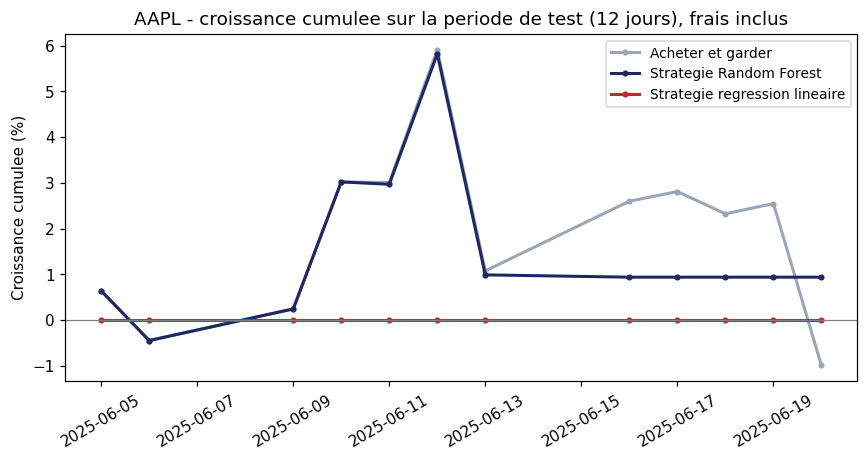

In [3]:
fig, ax = plt.subplots(figsize=(8, 4.3))
ax.plot(dates_test, croissance_bh*100, color="#9AA5B8", linewidth=2, marker="o", markersize=3, label="Acheter et garder")
ax.plot(dates_test, croissance_rf*100, color="#1E2761", linewidth=2, marker="o", markersize=3, label="Strategie Random Forest")
ax.plot(dates_test, croissance_lin*100, color="#C62828", linewidth=2, marker="o", markersize=3, label="Strategie regression lineaire")
ax.axhline(0, color="gray", linewidth=0.8)
ax.set_title("AAPL - croissance cumulee sur la periode de test (12 jours), frais inclus")
ax.set_ylabel("Croissance cumulee (%)")
ax.legend(fontsize=9)
plt.xticks(rotation=30)
plt.tight_layout()
plt.show()


## Pourquoi les frais de transaction changent tout

Une stratégie qui change de position tous les 2-3 jours peut sembler performante en rendement brut, mais chaque aller-retour coûte réellement de l'argent (frais de courtage, écart bid-ask, parfois fiscalité). Une stratégie à 4 transactions sur 12 jours, comme ici, se rapproche d'un trading actif — un profil de risque et de coûts très différent d'un investissement long terme. **Ce point doit toujours être présenté au client**, car c'est souvent le détail qui transforme un backtest "gagnant" en stratégie non rentable une fois déployée en réel.

## Conclusion générale du projet PricePredictor

En reliant les trois notebooks :

1. **Exploration** — les rendements d'AAPL se comportent, sur cet échantillon, comme un bruit quasi blanc (ACF/PACF sans structure marquée).
2. **Modélisation** — un modèle simple (Random Forest) fait légèrement mieux qu'une baseline naïve, mais l'écart n'est pas significatif sur un échantillon de 12 observations de test.
3. **Backtesting** — cette petite avance se traduit, sur cette fenêtre précise, par une performance positive une fois les frais inclus — mais rien ne garantit que ce résultat se reproduirait sur une autre période ou un autre titre.

**Réponse honnête à la question initiale du client :** un modèle de Machine Learning simple peut capter un signal marginal sur des données financières, mais ce signal est faible, instable, et sensible aux coûts de transaction. Il ne constitue pas, en l'état, une stratégie fiable pour un investisseur particulier — l'intérêt de ce projet est méthodologique (savoir construire et évaluer un pipeline de prédiction correctement) plutôt qu'opérationnel.

**Limites globales du projet :**
- Toutes les analyses portent sur des données simulées et un échantillon réduit (79 jours de cours, 12 jours de test).
- Une vraie validation nécessiterait plusieurs années de données réelles, une validation croisée temporelle (walk-forward), et un test sur plusieurs titres/secteurs plutôt qu'une seule action.
- Ce projet ne constitue en aucun cas un conseil en investissement ni une stratégie de trading prête à l'emploi.
